## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Evaluation BertMorphTaggerV1**](#hindamine_v1)
3. [**Results BertMorphTaggerV1**](#tulemused_v1)

[end](#end)


### Conclusive evaluation results for the model

### Macro average metrics

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model                                  | Accuracy | Precision | Recall | F1-score |
| -------------------------------------- | -------: | --------: | -----: | -------: |
| BertMorphTaggerV1                      |   89.40% |    25.87% | 22.17% |   23.48% |
| BertMorphTaggerV1 (lenient)            |   89.46% |    67.39% | 57.90% |   61.30% |
| BertMorphTaggerV1 (lenient, no others) |   89.63% |    84.24% | 72.50% |   76.69% |

Predictions outside the set of possible labels: **15/7886 (0.19%)**


### Imports


In [1]:
print("Test")

Test


In [2]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [3]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [4]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [5]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


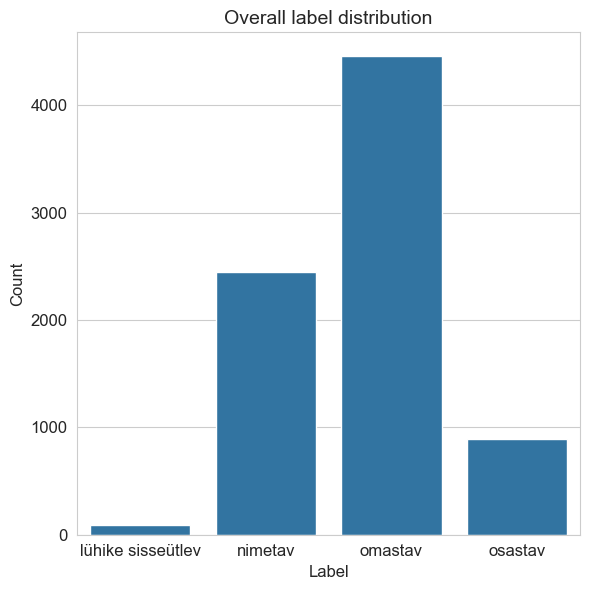

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_32032\3500709682.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


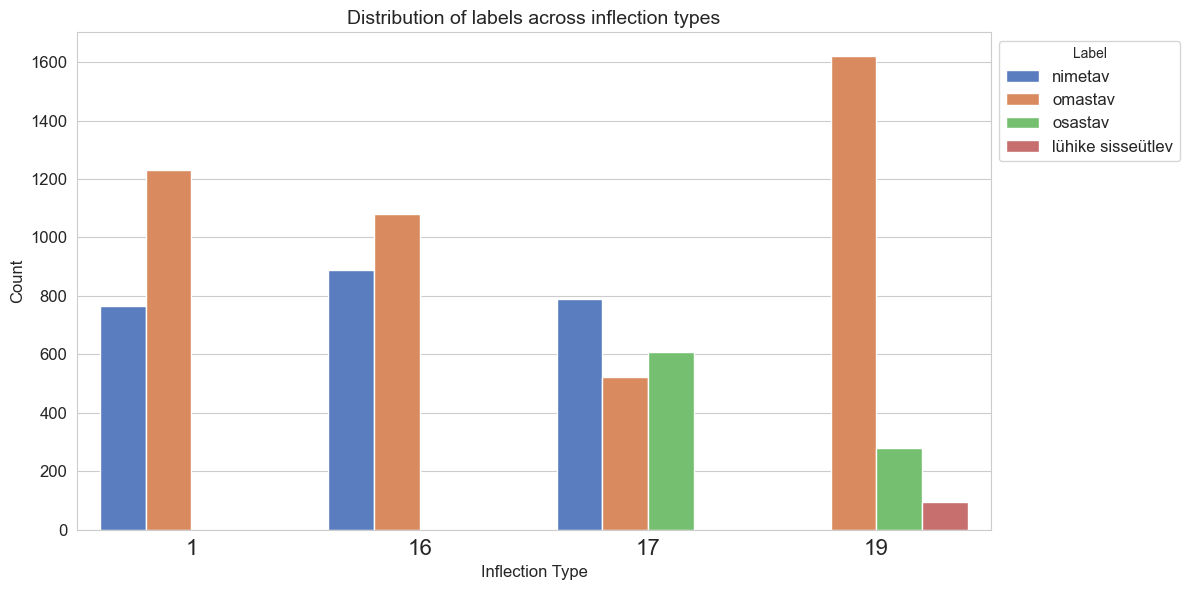

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike sisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Overall label distribution", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Distribution of labels across inflection types", fontsize=14)
plt.xlabel("Inflection Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.legend(title="Label", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='hindamine_v1'></a>


### Evaluation BertMorphTaggerV1


In [6]:
# Define model to use for annotation
model_path = "../models/NER_mudel/"
model_name = "BertMorphTaggerV1"
df_output_csv_path = str(
    HOMONYMS_DIRS["annotations"] / "homonyms_annotations_Bert_morph_V1.csv"
)

In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_path,
    output_csv_path=df_output_csv_path,
    progress_desc="Evaluating BertMorphTaggerV1 on homonyms dataset",
)

Evaluating BertMorphTaggerV1 on homonyms dataset:   0%|          | 9/7886 [00:00<08:57, 14.64it/s]

Evaluating BertMorphTaggerV1 on homonyms dataset: 100%|██████████| 7886/7886 [07:24<00:00, 17.75it/s]


In [ ]:
display(results_df.head())

,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",sg n,sg n,False,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",sg n,sg n,False,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",sg n,sg n,False,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",sg n,sg n,False,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",sg g,sg g,False,1,1


<a id='tulemused_v1'></a>


### Results BertMorphTaggerV1


In [7]:
# Load results dataframe
results_df = pd.read_csv(
    df_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

BertMorphTaggerV1 results:
Overall results
Accuracy:  89.40%
Precision: 25.87%
Recall:    22.17%
F1-score:  23.48%

BertMorphTaggerV1 results (lenient):
Overall results
Accuracy:  89.46%
Precision: 67.39%
Recall:    57.90%
F1-score:  61.30%

BertMorphTaggerV1 results (lenient, excluding 'other'):
Overall results
Accuracy:  89.63%
Precision: 84.24%
Recall:    72.50%
F1-score:  76.69%

Number of "other" cases: 15 out of 7886 (0.19%)


In [5]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV1 classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
           ?       0.00      0.00      0.00         0
         adt       0.72      0.35      0.47        94
          da       0.00      0.00      0.00         0
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg ad       0.00      0.00      0.00         0
        sg g       0.91      0.95      0.93      4457
      sg ill       0.00      0.00      0.00         0
        sg n       0.90      0.88      0.89      2445
        sg p       0.84      0.70      0.77       890

    accuracy                           0.89      7886
   macro avg       0.26      0.22      0.23      7886
weighted avg       0.89      0.89      0.89      7886

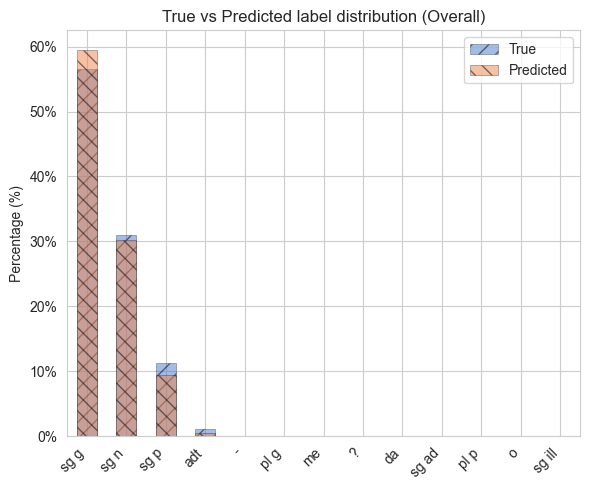

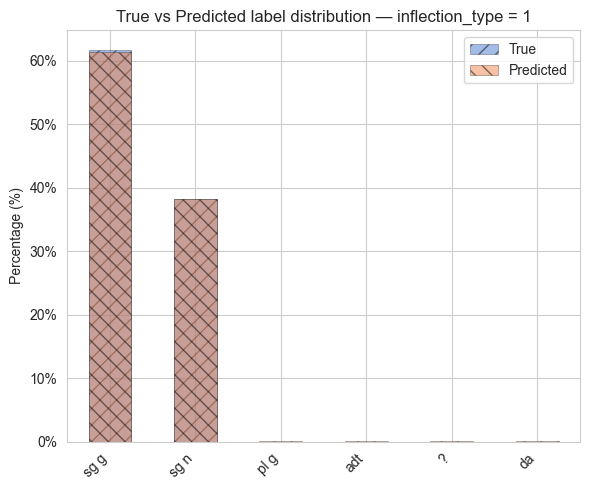

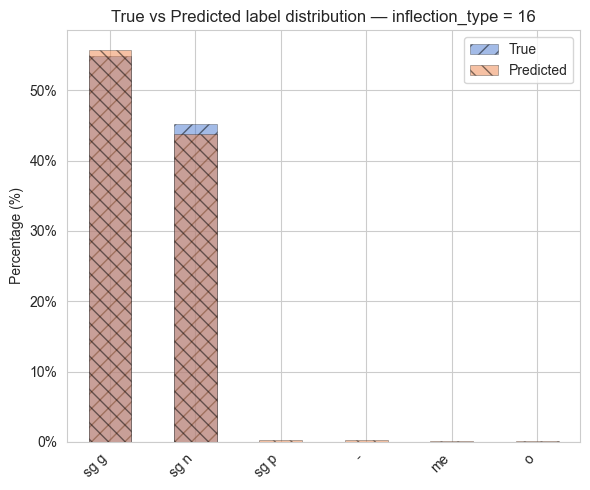

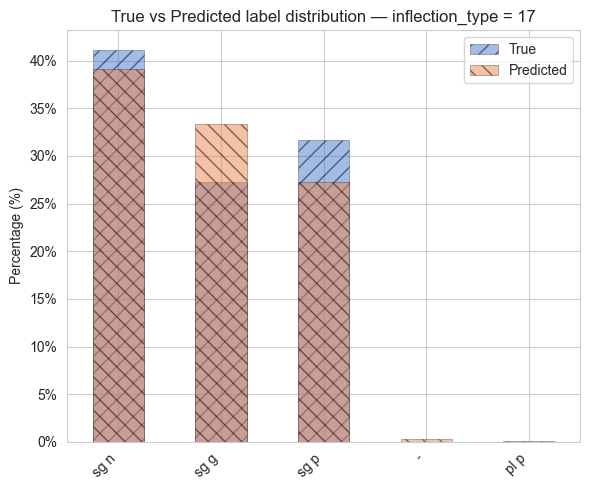

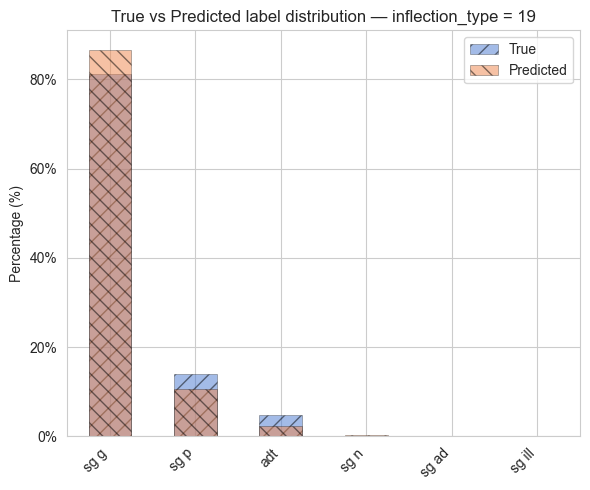

In [6]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

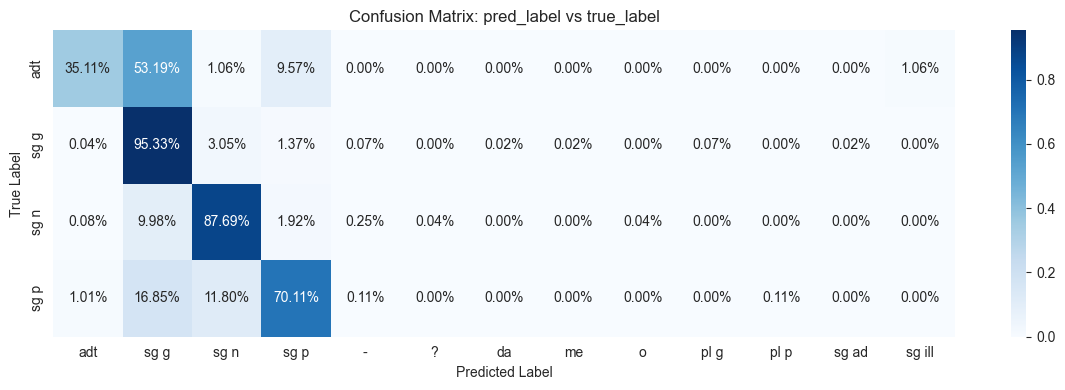

Confusion Matrix: pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -     10       0.13              True              0
1                 pl g      3       0.04              True              0
2                    ?      1       0.01              True              0
3                   me      1       0.01              True              0
4                   da      1       0.01              True              0
5                    o      1       0.01              True              0
6                 pl p      1       0.01              True              0
7                sg ad      1       0.01              True              0
8               sg ill      1       0.01              True              0
Sum of true labels count: 7886


In [7]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(12, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

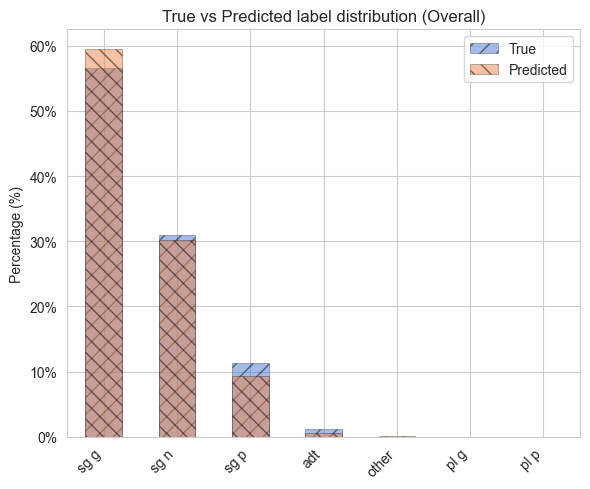

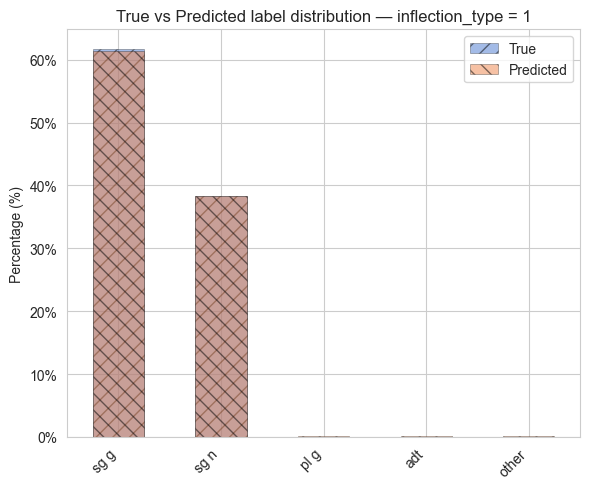

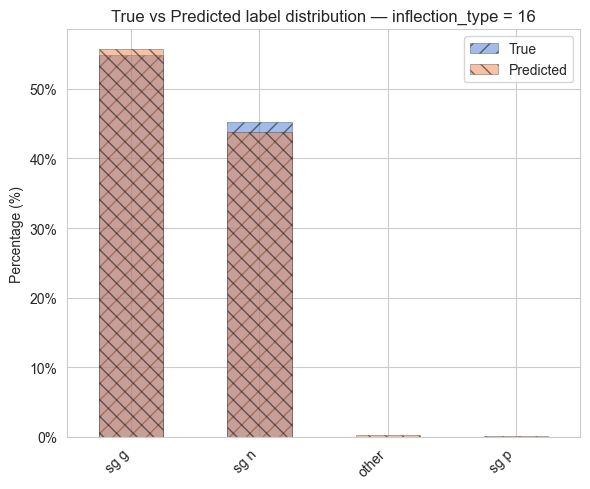

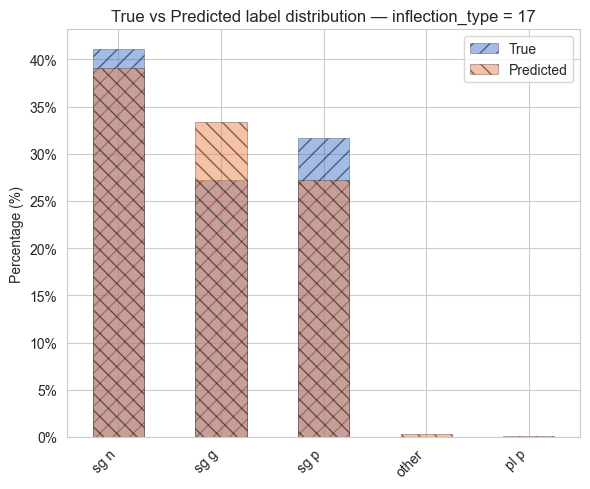

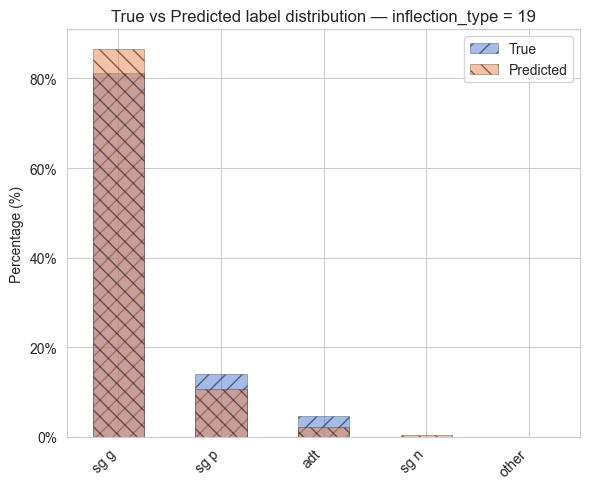

In [8]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

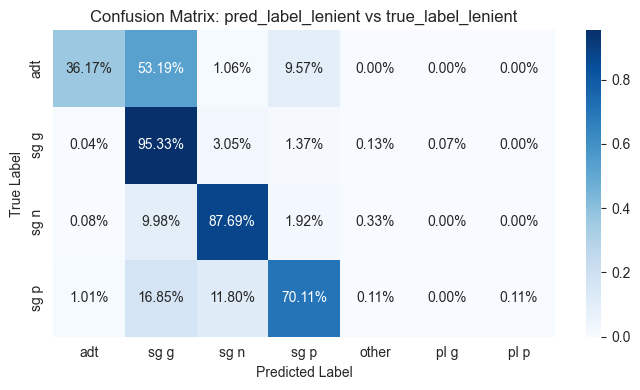

Confusion Matrix: pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     15       0.19              True              0
1                 pl g      3       0.04              True              0
2                 pl p      1       0.01              True              0
Sum of true labels count: 7886


In [9]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(7, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

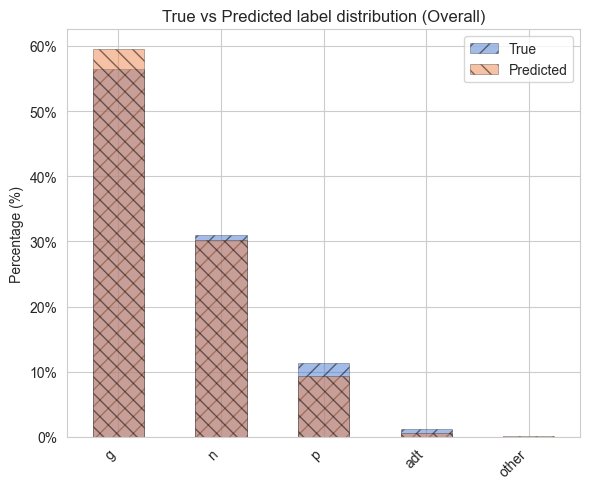

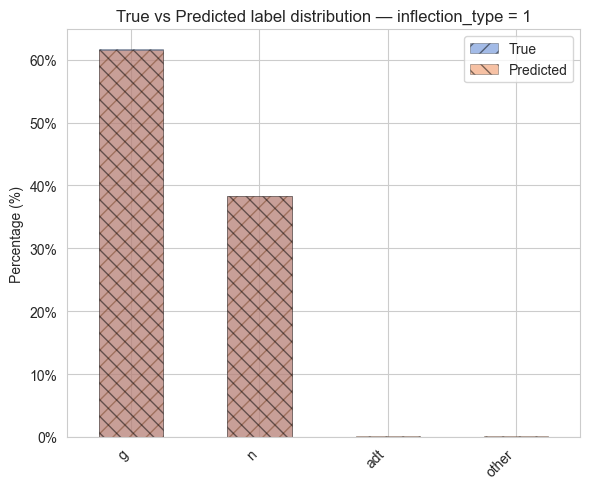

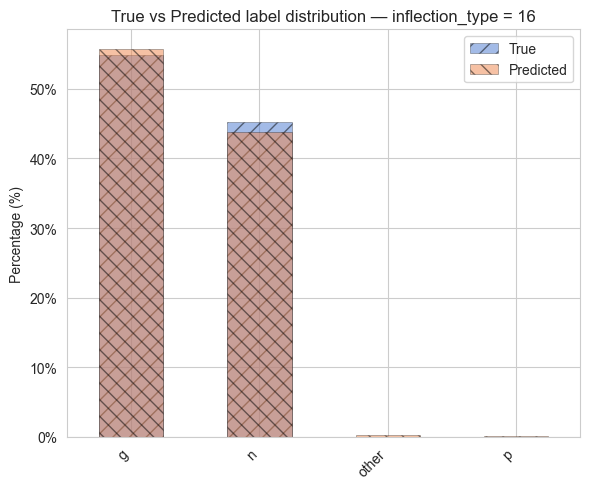

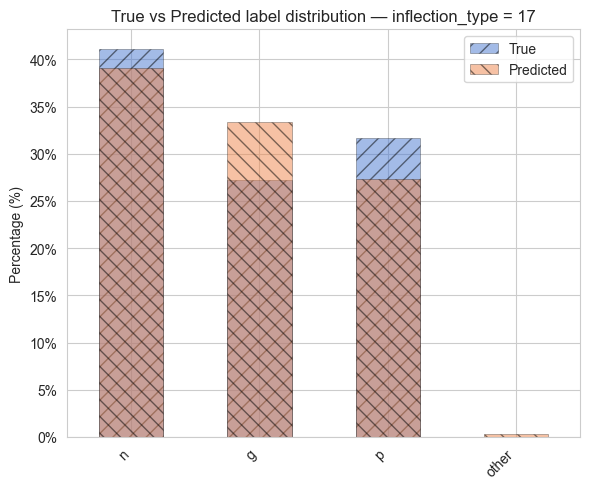

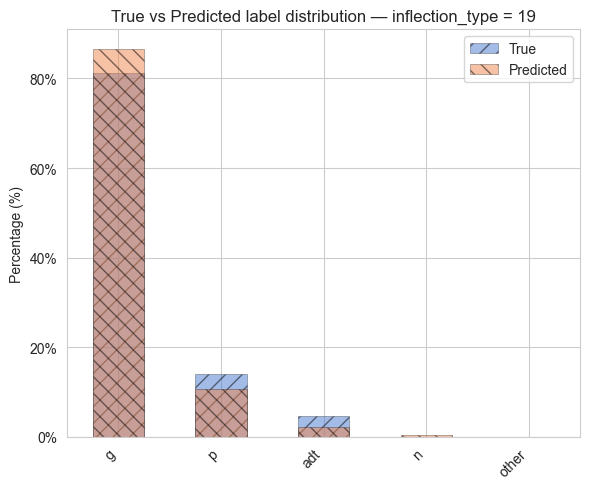

In [10]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

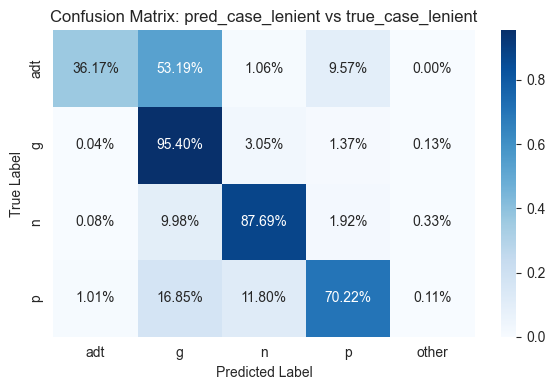

Confusion Matrix: pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     15       0.19              True              0
Sum of true labels count: 7886


In [11]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

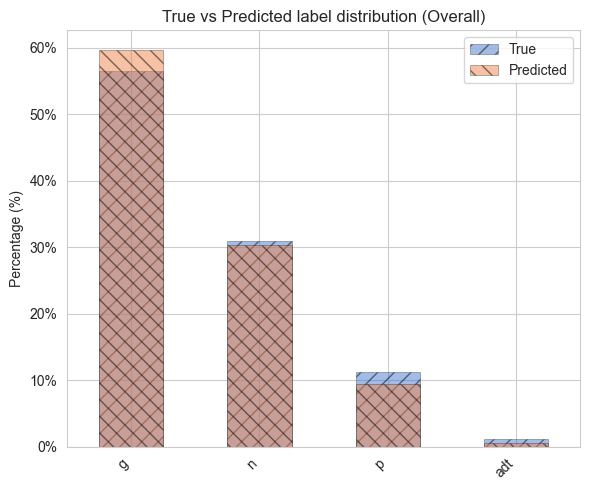

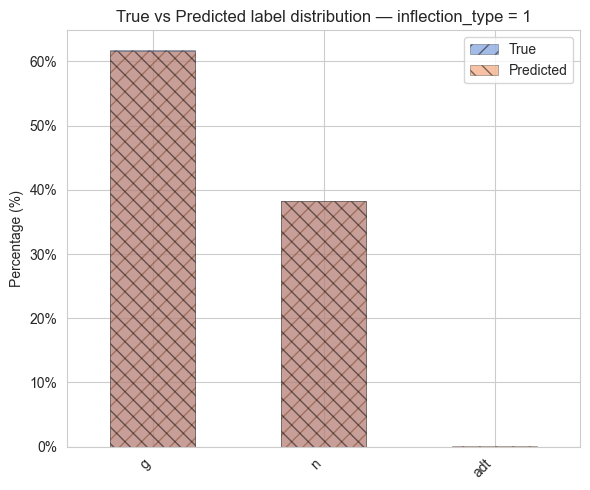

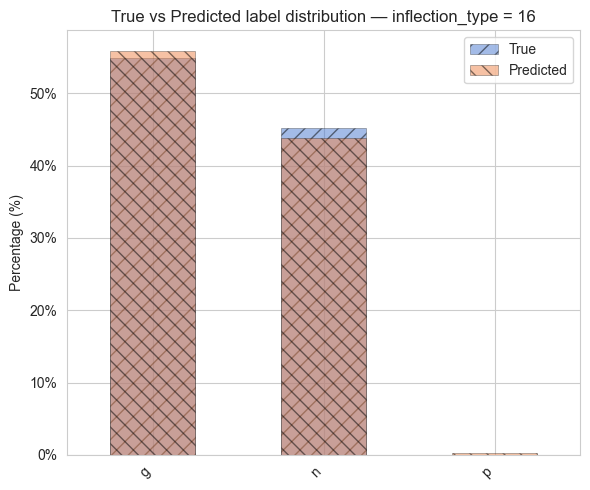

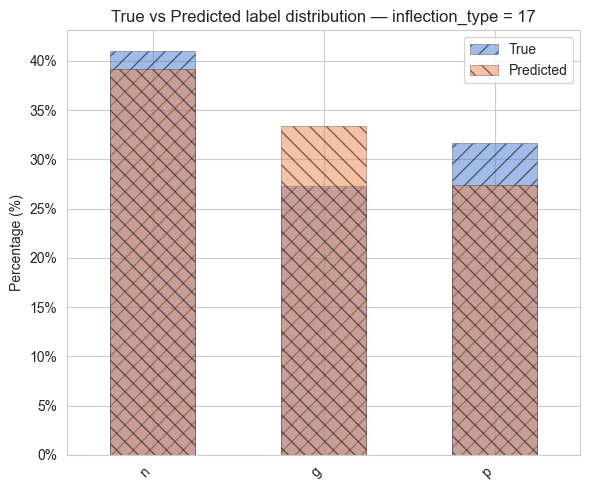

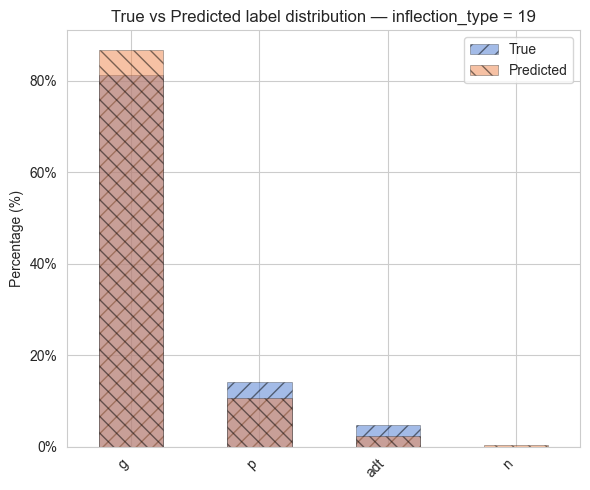

In [12]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

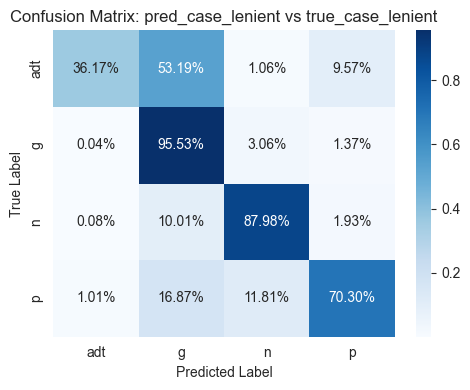

In [13]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(5, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [14]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV1 results per inflection type:
inflection_type=1
Accuracy:  93.49%
Precision: 93.82%
Recall:    93.49%
F1-score:  93.65%
inflection_type=16
Accuracy:  92.84%
Precision: 93.33%
Recall:    92.84%
F1-score:  93.07%
inflection_type=17
Accuracy:  80.56%
Precision: 81.53%
Recall:    80.56%
F1-score:  80.66%
inflection_type=19
Accuracy:  90.43%
Precision: 90.23%
Recall:    90.43%
F1-score:  89.71%


In [15]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV1 classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

           ?       0.00      0.00      0.00         0
         adt       0.00      0.00      0.00         0
          da       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        sg g       0.95      0.95      0.95      1232
        sg n       0.92      0.92      0.92       764

    accuracy                           0.93      1996
   macro avg       0.31      0.31      0.31      1996
weighted avg       0.94      0.93      0.94      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        sg g       0.93      0.95      0.94      1080
        sg n       0.94      0.91      

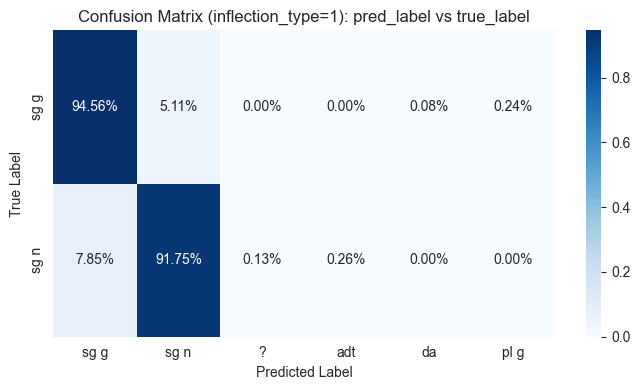

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl g      3       0.15              True              0
1                  adt      2       0.10              True              0
2                    ?      1       0.05              True              0
3                   da      1       0.05              True              0
Sum of true labels count: 1996


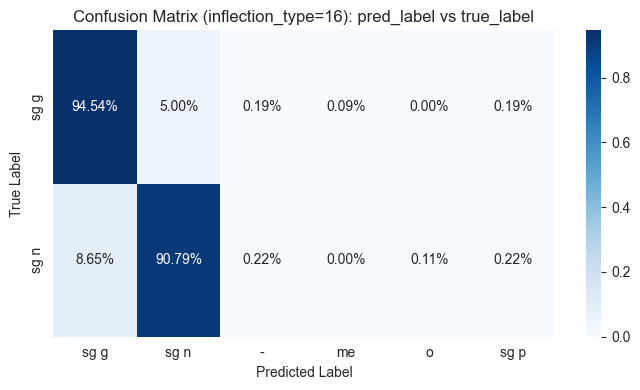

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      4       0.20              True              0
1                 sg p      4       0.20              True              0
2                   me      1       0.05              True              0
3                    o      1       0.05              True              0
Sum of true labels count: 1970


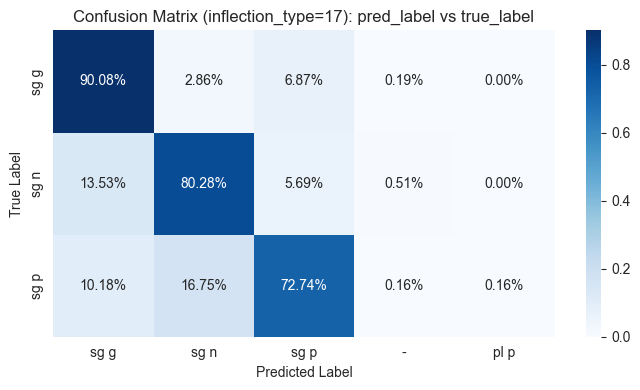

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      6       0.31              True              0
1                 pl p      1       0.05              True              0
Sum of true labels count: 1924


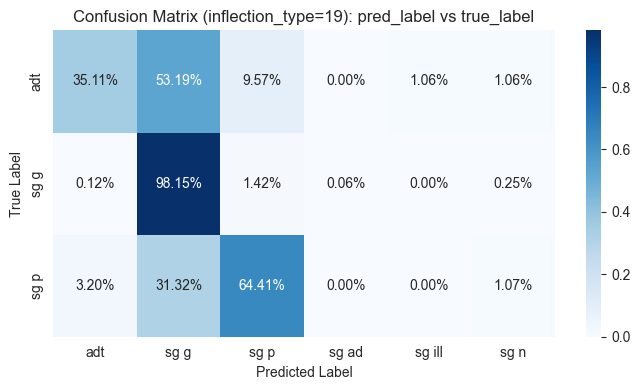

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      8       0.40              True              0
1                sg ad      1       0.05              True              0
2               sg ill      1       0.05              True              0
Sum of true labels count: 1996


In [16]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(7, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

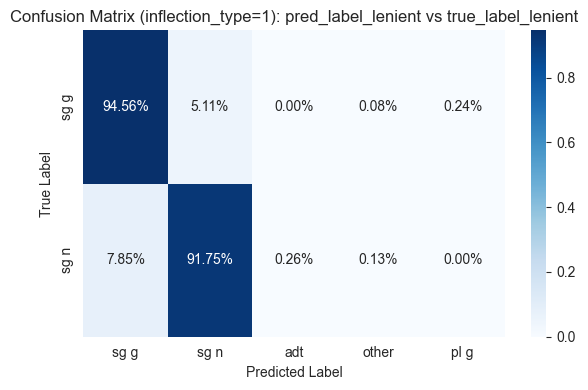

Confusion Matrix (inflection_type=1): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl g      3       0.15              True              0
1                  adt      2       0.10              True              0
2                other      2       0.10              True              0
Sum of true labels count: 1996


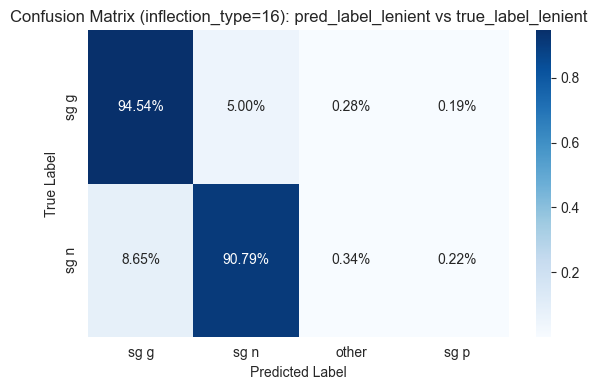

Confusion Matrix (inflection_type=16): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      6        0.3              True              0
1                 sg p      4        0.2              True              0
Sum of true labels count: 1970


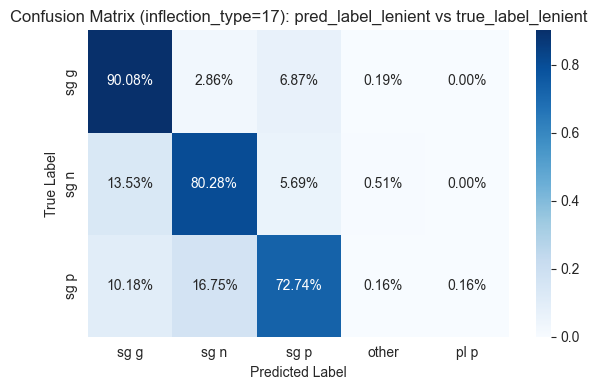

Confusion Matrix (inflection_type=17): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      6       0.31              True              0
1                 pl p      1       0.05              True              0
Sum of true labels count: 1924


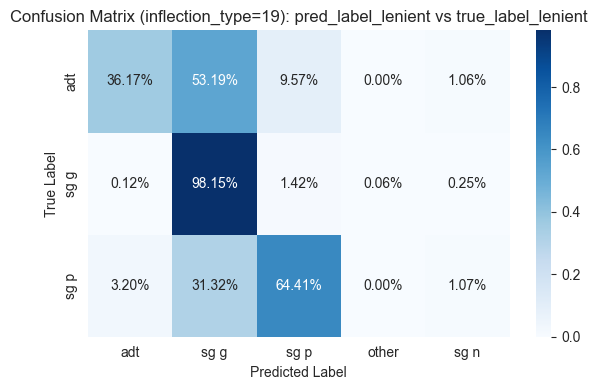

Confusion Matrix (inflection_type=19): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      8       0.40              True              0
1                other      1       0.05              True              0
Sum of true labels count: 1996


In [17]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

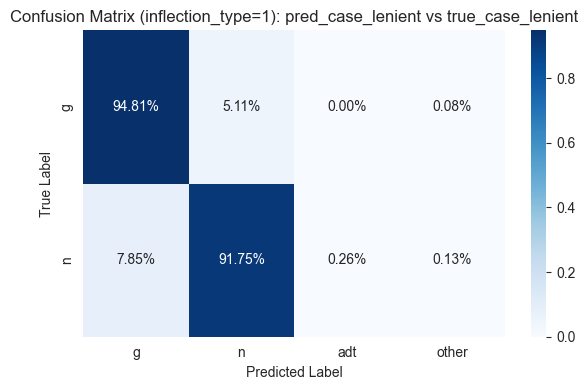

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      2        0.1              True              0
1                other      2        0.1              True              0
Sum of true labels count: 1996


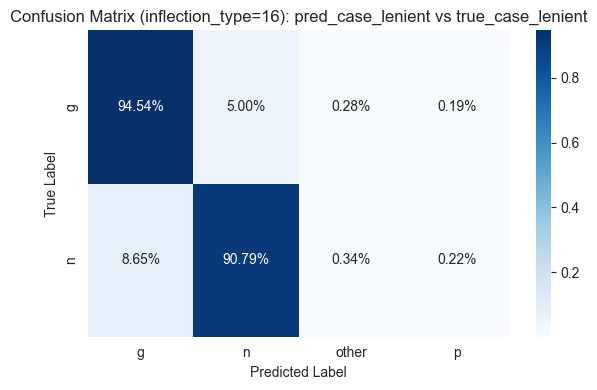

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      6        0.3              True              0
1                    p      4        0.2              True              0
Sum of true labels count: 1970


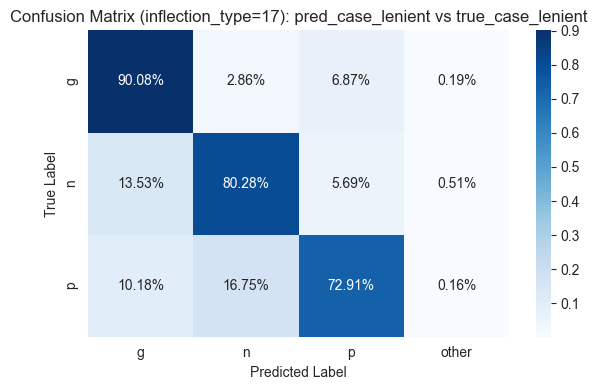

Confusion Matrix (inflection_type=17): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      6       0.31              True              0
Sum of true labels count: 1924


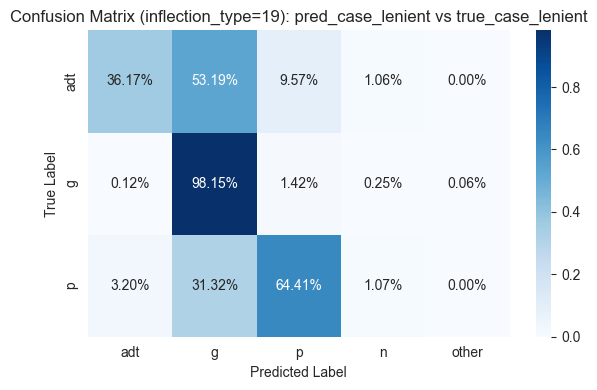

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      8       0.40              True              0
1                other      1       0.05              True              0
Sum of true labels count: 1996


In [18]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

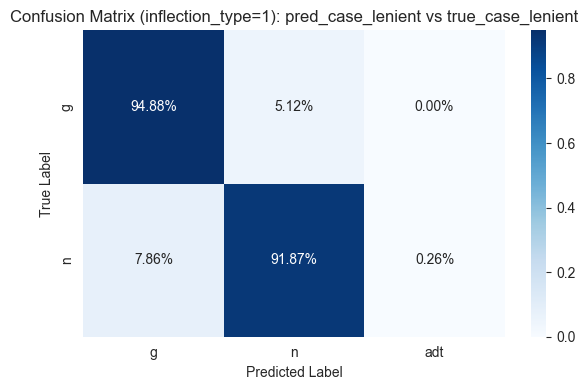

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      2        0.1              True              0
Sum of true labels count: 1994


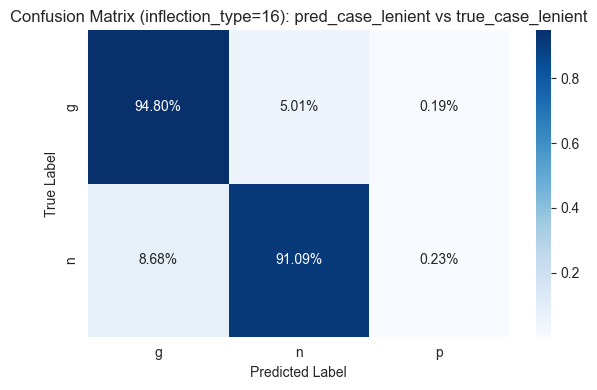

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p      4        0.2              True              0
Sum of true labels count: 1964


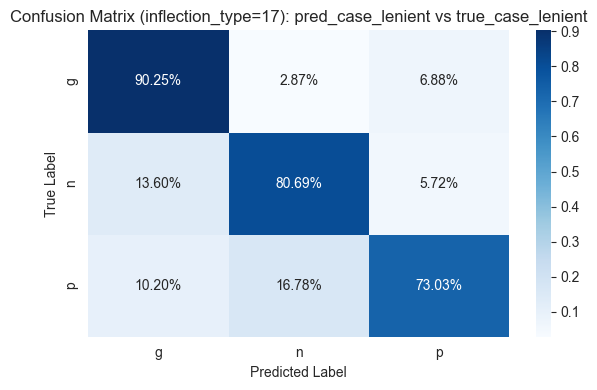

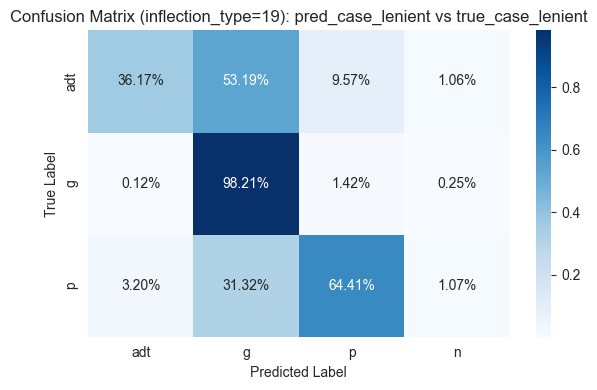

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      8        0.4              True              0
Sum of true labels count: 1995


In [19]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

In [20]:
# Analyse results where model predicted wrong
incorrect_df = results_df[results_df["pred_label"] != results_df["true_label"]]
number_to_sample = 1
# Create a df of incorrect predictions by sampling 5 random examples per inflection type + label group
cols = [c for c in incorrect_df.columns if c not in ["inflection_type", "true_label"]]
examples_to_show = (
    incorrect_df.groupby(["inflection_type", "true_label"])[cols]
    .apply(
        lambda x: (
            x.sample(n=number_to_sample, random_state=SEED)
            if len(x) >= number_to_sample
            else x
        )
    )
    .reset_index(level=[0, 1])
    .reset_index(drop=True)
)
print("Examples of incorrect predictions by the model:")
display_examples(
    dataset=examples_to_show,
    num_examples=20,
    display_or_print="print",
    list_of_columns_to_show=examples_to_show.columns.tolist(),
)

Examples of incorrect predictions by the model:
Example 1 (index 0):
  inflection_type: 1
  true_label: sg g
  sentence: Kuriteoks soodne pinnas tekkis 1997. aastal, kui Boeing meelitas endale ühe Lockheed Martini töötaja, kes tõi dokumendid endaga kaasa.
  word: töötaja
  word_span: (np.int64(93), np.int64(100))
  pred_label: sg n
  ambiguous: False
  num: 2
----------------------------------------
Example 2 (index 1):
  inflection_type: 1
  true_label: sg n
  sentence: Rollid vahetusid : aasta tagasi langes Visnapuu poolfinaali viiendas mängus BC Tallinna vastu Aivar Kuusmaa ohvriks.
  word: aasta
  word_span: (np.int64(19), np.int64(24))
  pred_label: sg g
  ambiguous: False
  num: 2
----------------------------------------
Example 3 (index 2):
  inflection_type: 16
  true_label: sg g
  sentence: Enamasti toovad kliendid ise auto tagasi.
  word: auto
  word_span: (np.int64(29), np.int64(33))
  pred_label: sg n
  ambiguous: False
  num: 1
----------------------------------------
Exam

## END
